In [1]:
initial_dna_sequence = [
    'A', 'ALPHA',
    'B', 'BETA',
    'C', 'GAMMA',
    'D', 'DELTA',
    'E', 'EPSILON',
    'F', 'ZETA',
    'G', 'ETA',
    'H', 'THETA',
    'I', 'IOTA',
    'J', 'KAPPA',
    'K', 'LAMBDA',
    'L', 'MU',
    'M', 'NU',
    'N', 'XI',
    'O', 'OMICRON',
    'P', 'PI',
    'Q', 'RHO',
    'R', 'SIGMA',
    'S', 'TAU',
    'T', 'UPSILON',
    'U', 'PHI',
    'V', 'CHI',
    'W', 'PSI',
    'X', 'OMEGA',
    'DELTA', 'D'
]


In [2]:
initial_dna_sequence= [
    'A', 'ALPHA', 'BETA', 'B',
    'A', 'ALPHA', 'BETA', 'B',
    'A', 'ALPHA', 'BETA', 'B',
    'A', 'ALPHA', 'BETA', 'B',
    'A', 'ALPHA', 'BETA', 'B'
]





In [3]:
initial_dna_sequence=[
'1', 'A', 'ALPHA',
'2', 'ALPHA', 'A',
'3','A','ALPHA',
'4','ALPHA','A',
'5','A','ALPHA',
'6','ALPHA','A',
'7','A','ALPHA',
'8','ALPHA','A',
'9','A','ALPHA',
'10','ALPHA','A',
'11']

In [4]:
initial_dna_sequence=[
'1', 'A', 'ALPHA',
'2', 'BETA', 'B',
'3', 'A', 'ALPHA',
'4', 'BETA', 'B',
'5']

In [5]:
initial_dna_sequence=[
'1', 'A', 'ALPHA',
'2', 'BETA', 'B',
'3', 'A', 'ALPHA',
'4', 'BETA', 'B',
'5', 'A', 'ALPHA',
'6', 'BETA', 'B',
'7', 'A', 'ALPHA',
'8', 'BETA', 'B',
'9', 'A', 'ALPHA',
'10', 'BETA', 'B',
'11']





In [6]:
# -*- coding: utf-8 -*-

class CompositeElement:
    def __init__(self, name):
        self.name = name
        self._composite = None
    
    def composite(self):
        return self._composite
    
    def set_composite(self, other):
        self._composite = other

class CompositeMapping:
    def __init__(self):
        self.elements = {}
    
    def add_pair(self, element1, element2):
        # Create CompositeElement instances if they don't exist
        if element1 not in self.elements:
            self.elements[element1] = CompositeElement(element1)
        if element2 not in self.elements:
            self.elements[element2] = CompositeElement(element2)
        
        # Set up the composite relationship
        self.elements[element1].set_composite(self.elements[element2])
        self.elements[element2].set_composite(self.elements[element1])
    
    def get_element(self, name):
        return self.elements.get(name)





def create_mapping():# Check encoding first
    
    # Create a composite mapping
    composite_mapping = CompositeMapping()
    
    # Define all the letter sets
    latin_upper = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    latin_lower = 'abcdefghijklmnopqrstuvwxyz'

    
    # Define Latin names
    latin_names_upper = [
        'ALPHA', 'BETA', 'GAMMA', 'DELTA', 'EPSILON', 'ZETA', 'ETA', 'THETA',
        'IOTA', 'KAPPA', 'LAMBDA', 'MU', 'NU', 'XI', 'OMICRON', 'PI', 'RHO',
        'SIGMA', 'TAU', 'UPSILON', 'PHI', 'CHI', 'PSI', 'OMEGA'
    ]
    latin_names_lower = [name.lower() for name in latin_names_upper]

    
    
    # 1. Latin uppercase to uppercase prime
    for letter in latin_upper:
        composite_mapping.add_pair(letter, f"{letter}_prime")
    
    # 2. Latin lowercase to lowercase prime
    for letter in latin_lower:
        composite_mapping.add_pair(letter, f"{letter}_prime")
    
    
    # 5. Latin names uppercase to uppercase prime
    for name in latin_names_upper:
        composite_mapping.add_pair(name, f"{name}_prime")
    
    # 6. Latin names lowercase to lowercase prime
    for name in latin_names_lower:
        composite_mapping.add_pair(name, f"{name}_prime")

    # 7. Numbers to uppercase prime
    for number in range(1, 12):
        composite_mapping.add_pair(str(number), f"{str(number)}_prime")

    return composite_mapping


    
composite_mapping=create_mapping()



In [7]:
A=CompositeElement("A")
A.set_composite(CompositeElement("A_prime"))

print(A._composite.name)






A_prime


In [8]:
def inverse_composite(sequence):
    inverse_composite=sequence[::-1]
    for i in range(len(inverse_composite)):
        inverse_composite[i]=composite_mapping.elements[inverse_composite[i]]._composite.name
    return inverse_composite


In [9]:

def detect_forward_sites(DNA,site):
    site_length = len(site)
    start_positions = []
    end_positions = []
    
    # Slide through the DNA looking for matches
    for i in range(len(DNA) - site_length + 1):
        # Check if current window matches the site
        if DNA[i:i+site_length] == site:
            start_positions.append(i)#computer positions
    
    return start_positions


In [10]:

def detect_backward_sites(DNA,site):
    site_length = len(site)
    start_positions = []
    end_positions = []
    
    # Slide through the DNA looking for matches
    for i in range(len(DNA) - site_length + 1):
        # Check if current window matches the site
        if DNA[i:i+site_length] == site:
            start_positions.append(i)#computer positions
    
    return start_positions


In [11]:


def delete_between(DNA,site_1,site_2):
    return DNA[:site_1]+DNA[site_2:]  

def invert_between(DNA,site_1,site_2):
    return DNA[:site_1]+inverse_composite(DNA[site_1:site_2])+DNA[site_2:] 



In [12]:


def evaluate_colour_CRE(DNA,choice1,choice2):

    num1, direction_1 = choice1
    num2, direction_2 = choice2
    #WLOG,make num 1 the smaller one
    if num1 > num2:
        num1, num2 = num2, num1
    
    # Determine which function to use
    
    if direction_1 == 'forward':
        if direction_1 == direction_2:
            result= delete_between(DNA,num1+1,num2+1)
        elif direction_1!=direction_2:
            result= invert_between(DNA,num1+1,num2+1)
    elif direction_1=='backward':
        if direction_1 == direction_2:
            result= delete_between(DNA,num1+1,num2+1)
        else :
            result= 'DoNotCount'

    return result








In [13]:
def probability_calculation(DNA,pairs_pool,num_recombinases=10):
    # Dictionary to store counts of each outcome
    outcome_list=[{tuple(DNA):1}]

    for _ in range(num_recombinases):
        outcome_list.append({})
    recombinases_event=  0


    # Run simulations
    for stage in outcome_list:
        if recombinases_event<len(outcome_list)-1:
            recombinases_event+=1      
            for stored_result,probabilities in stage.items():
                stored_result=list(stored_result)
                num_arrows=0
                for pair in pairs_pool:
                    forward_sites=pair[0]
                    backward_sites=pair[1]
                
                    forward_9_positions=detect_forward_sites(stored_result,forward_sites)
                    backward_6_positions=detect_backward_sites(stored_result,backward_sites)
                    # Randomly select two sites
                    forward = [(num, 'forward') for num in forward_9_positions] 
                    backward= [(num, 'backward') for num in backward_6_positions]
                    if 1==1:#wierd logic due to historical reasons
                        
                        num_arrows=len(forward)*len(backward)
                        
                        for i in forward:
                            for j in backward:
                                choice1,choice2 = i, j
                                if choice1[0]>choice2[0]:
                                    break
                                
                                output = evaluate_colour_CRE(stored_result,choice1,choice2)
                                #while output=='DoNotCount':
                                #    output=evaluate_colour_CRE(stored_result,choice1,choice2)
                                if output!='DoNotCount':
                                    formatted_output = tuple(output)
                                    #print(formatted_output)#!!!Remove before flight  
                                    if formatted_output not in outcome_list[recombinases_event]:
                                        outcome_list[recombinases_event][formatted_output] = 0
                                    outcome_list[recombinases_event][formatted_output] +=2*probabilities/num_arrows
                        
        print('stage',recombinases_event,'completed')
    return outcome_list

In [14]:
data={}
pairs_pool=[(['A','ALPHA'],['BETA','B']),(['A','BETA_prime'],['ALPHA_prime','B']),(['A','ALPHA'],['ALPHA','A'])]
#pairs_pool=[(['A','ALPHA'],['ALPHA','A'])]
outcome_lists= probability_calculation(initial_dna_sequence,pairs_pool,num_recombinases=50)


stage 1 completed
stage 2 completed
stage 3 completed
stage 4 completed
stage 5 completed
stage 6 completed
stage 7 completed
stage 8 completed
stage 9 completed
stage 10 completed
stage 11 completed
stage 12 completed
stage 13 completed
stage 14 completed
stage 15 completed
stage 16 completed
stage 17 completed
stage 18 completed
stage 19 completed
stage 20 completed
stage 21 completed
stage 22 completed
stage 23 completed
stage 24 completed
stage 25 completed
stage 26 completed
stage 27 completed
stage 28 completed
stage 29 completed
stage 30 completed
stage 31 completed
stage 32 completed
stage 33 completed
stage 34 completed
stage 35 completed
stage 36 completed
stage 37 completed
stage 38 completed
stage 39 completed
stage 40 completed
stage 41 completed
stage 42 completed
stage 43 completed
stage 44 completed
stage 45 completed
stage 46 completed
stage 47 completed
stage 48 completed
stage 49 completed
stage 50 completed
stage 50 completed


In [15]:

stored_data=(outcome_lists)

In [16]:
import matplotlib.pyplot as plt
import numpy as np





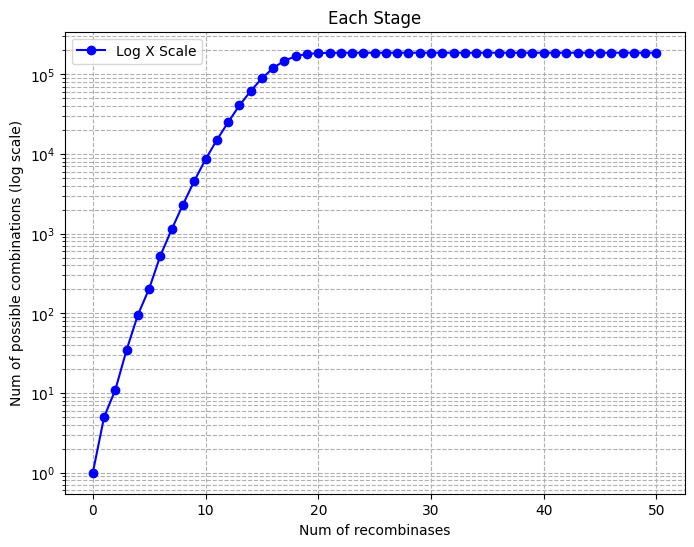

In [17]:
x=[]
y=[]
for i in range(len(outcome_lists)):
    x.append(i)
    if i==0:
        y.append(len(outcome_lists[i]))
    elif i >0:
        y.append(len(outcome_lists[i]))


# Create a figure and axis
plt.figure(figsize=(8, 6))

# Plot the line graph with log scale on the x-axis
plt.semilogy(x, y, marker='o', linestyle='-', color='b', label='Log X Scale')

# (Alternatively, for log y-axis: plt.semilogy(x, y, ...))
# (For both axes log: plt.loglog(x, y, ...))

# Add labels and title
plt.xlabel('Num of recombinases')
plt.ylabel('Num of possible combinations (log scale)')

plt.legend()
plt.grid(True, which="both", ls="--")
plt.title("Each Stage")

plt.show()

In [18]:
import math
def calculate_entropy(prob_dict):
    """
    Calculate Shannon entropy (in bits) for a dictionary of outcome probabilities.
    
    Args:
        prob_dict (dict): Dictionary where keys are outcomes and values are probabilities.
    
    Returns:
        float: Entropy in bits.
    """
    entropy = 0.0
    for prob in prob_dict.values():
        if prob > 0:  # Avoid log(0) which is undefined
            entropy -= prob * math.log2(prob)
    return entropy

[0.0, 1.4575424759098898, 1.627890539245055, 3.804605642330829, 3.455397926946595, 6.968429417385537, 7.077967778550243, 12.507667421633363, 13.477643190113689, 22.506283436091092, 24.765052563428, 40.00293558016487, 44.418198531729914, 69.9491011705927, 77.96205538136292, 120.16819260617359, 133.97234181006453, 202.59318311514994, 225.16819897828455, 334.5332592928096, 369.0982873226564, 539.107633874227, 586.9212017931028, 842.5266296045429, 896.5297207158004, 1262.5685424839105, 1291.2659827162568, 1775.3008135675964, 1684.6935397929926, 2231.495920373764, 1779.1335616421966, 2161.4901295999957, 768.3903188873186, 339.6682436957013, -3311.905528441992, -6158.218780472448, -14969.865056083996, -23950.799122861376, -44158.919216205264, -67505.92885535557, -112268.33958747245, -167677.41635634127, -264351.1376951343, -389060.14480680623, -593852.3124355614, -864967.0198049699, -1292229.502745418, -1867408.5486759106, -2747871.5364736384, -3946239.784178012, -5742184.546253309]


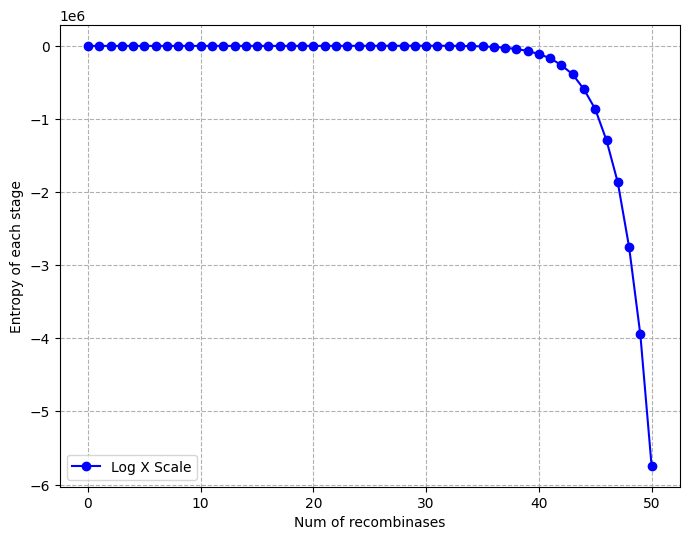

In [19]:
entropy_list=[]
for _ in outcome_lists:
    entropy_list.append(calculate_entropy(_))
print(entropy_list)
    
x=[]
y=[]
for i in range(len(entropy_list)):
    x.append(i)
    y.append(entropy_list[i])


# Create a figure and axis
plt.figure(figsize=(8, 6))

# Plot the line graph with log scale on the x-axis
plt.plot(x, y, marker='o', linestyle='-', color='b', label='Log X Scale')

# (Alternatively, for log y-axis: plt.semilogy(x, y, ...))
# (For both axes log: plt.loglog(x, y, ...))

# Add labels and title
plt.xlabel('Num of recombinases')
plt.ylabel('Entropy of each stage')
plt.title
plt.legend()
plt.grid(True, which="both", ls="--")

plt.show()